
# Pose Quality Check + Preprocessing Pipeline 

This notebook performs two stages:

1. **QC (Quality Control)** — counts and lists 'bad' windows for each metric.
2. **Preprocessing** — aggregates OpenPose keypoints into regions, then **masks only** those metric-windows flagged as bad by QC.

**How to use:** Set everything in the first **Parameters** cell, then run cells in order.


# Parameters

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analyze_pose.preprocessing import *

# ============================ PARAMETERS (EDIT ME) ============================
# High-level switch (optional): choose data blocks to process
MODE = "baseline"   # options: "baseline", "experimental"

# I/O directories (override if you want explicit paths)
DIRS = {
    "baseline": {
        "qc_output": "data/qc_outputs_bsl",
        "raw_input": "data/raw_pose/baseline_pose",
        "preproc_output": "data/preprocessed_pose/baseline_pose",
    },
    "experimental": {
        "qc_output": "data/qc_outputs_exp",
        "raw_input": "data/raw_pose/experimental_pose",
        "preproc_output": "data/preprocessed_pose/experimental_pose",
    },
}

# --- QC Parameters ---
WINDOW_SIZE = 1800              # frames per window (60s * 30fps)
OVERLAP = 0.0                   # no overlap
CONFIDENCE_THRESHOLD = 0.3      # min confidence for valid landmarks
MAX_INTERP = 60                 # max consecutive missing frames

# --- Processing Parameters ---
COORDINATE_SYSTEM = "procrustes"  # or "original"
APPLY_BUTTERWORTH = True
SAMPLING_RATE = 60.0            # Hz
CUTOFF_FREQUENCY = 10.0         # Hz
FILTER_ORDER = 4

# QC metric to feature column mapping (case-insensitive keys expected from QC stage)
QC_TO_COLUMNS = {
    "eyes": [
        "blink_dist",
        "left_eye_x", "left_eye_y", "left_eye_prob", "left_eye_magnitude",
        "right_eye_x", "right_eye_y", "right_eye_prob", "right_eye_magnitude",
    ],
    "head_rotation": ["head_rotation_angle"],
    "mouth_dist": ["mouth_dist"],
    "pupils_combined": [
        "avg_pupil_x", "avg_pupil_y", "avg_pupil_magnitude",
        "left_pupil_x", "left_pupil_y", "left_pupil_prob", "left_pupil_magnitude",
        "right_pupil_x", "right_pupil_y", "right_pupil_prob", "right_pupil_magnitude",
    ],
    "center_face": [
        "center_face_x", "center_face_y", "center_face_prob", "center_face_magnitude",
    ],
}
# ============================================================================

# ---- Derived paths from MODE ----
RAW_INPUT_DIR       = DIRS[MODE]["raw_input"]
QC_OUTPUT_DIR       = DIRS[MODE]["qc_output"]
PREPROC_OUTPUT_DIR  = DIRS[MODE]["preproc_output"]
QC_BAD_IDX_FILE     = f"{QC_OUTPUT_DIR}/metric_bad_window_indices.csv"

# ---- Ensure directories exist (for both modes, handy if you switch later) ----
for mode_key, paths in DIRS.items():
    os.makedirs(paths["qc_output"], exist_ok=True)
    os.makedirs(paths["preproc_output"], exist_ok=True)
# RAW input dirs are expected to already exist (created by your data ingest)

# ---- Sanity echo ----
print("MODE:", MODE)
print("RAW input:", RAW_INPUT_DIR)
print("QC output:", QC_OUTPUT_DIR)
print("Preprocessed output:", PREPROC_OUTPUT_DIR)
print("QC bad-index CSV (created by QC, read by preprocessing):", QC_BAD_IDX_FILE)
print("Coordinate System:", COORDINATE_SYSTEM)
print("Butterworth:", "on" if APPLY_BUTTERWORTH else "off")
print("Window/Overlap:", WINDOW_SIZE, OVERLAP)

MODE: baseline
RAW input: data/raw_pose/baseline_pose
QC output: data/qc_outputs_bsl
Preprocessed output: data/preprocessed_pose/baseline_pose
QC bad-index CSV (created by QC, read by preprocessing): data/qc_outputs_bsl/metric_bad_window_indices.csv
Coordinate System: procrustes
Butterworth: on
Window/Overlap: 1800 0.0


# Plot check for keypoints

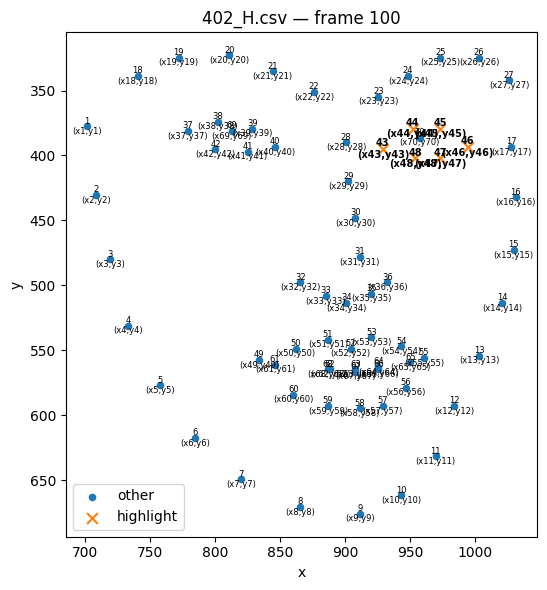

In [3]:
def _available_kp_indices(df, prefix='x'):
    """Return sorted ints i for which columns x{i}, y{i} exist."""
    pat = re.compile(rf'^{prefix}(\d+)$')
    idx = []
    for c in df.columns:
        m = pat.match(c)
        if m and f'y{m.group(1)}' in df.columns:
            idx.append(int(m.group(1)))
    return sorted(set(idx))

def plot_pose_frame(csv_path, frame=0, conf_thresh=None, highlight=range(35,36), figsize=(6,6)):
    """
    Plot raw keypoints for one frame with index labels AND CSV column names.
    """
    df = pd.read_csv(csv_path)
    if frame < 0 or frame >= len(df):
        raise IndexError(f"frame {frame} out of range [0, {len(df)-1}]")

    ks = _available_kp_indices(df)
    if not ks:
        raise ValueError("No keypoint columns like x{i}/y{i} found.")

    def present(i):
        if conf_thresh is not None and f'prob{i}' in df.columns:
            return (pd.notna(df.loc[frame, f'prob{i}']) 
                    and df.loc[frame, f'prob{i}'] >= conf_thresh)
        return pd.notna(df.loc[frame, f'x{i}']) and pd.notna(df.loc[frame, f'y{i}'])

    xs, ys, labels = [], [], []
    xs_h, ys_h, labels_h = [], [], []
    H = set(highlight) if highlight is not None else set()

    for i in ks:
        if not present(i):
            continue
        xi, yi = df.loc[frame, f'x{i}'], df.loc[frame, f'y{i}']
        lbl = f"{i}\n(x{i},y{i})"
        if i in H:
            xs_h.append(xi); ys_h.append(yi); labels_h.append(lbl)
        else:
            xs.append(xi); ys.append(yi); labels.append(lbl)

    plt.figure(figsize=figsize)
    plt.scatter(xs, ys, s=20, label="other")
    if labels_h:
        plt.scatter(xs_h, ys_h, s=60, marker='x', label="highlight")
    for xi, yi, lbl in zip(xs, ys, labels):
        plt.text(xi, yi, lbl, fontsize=6, ha='center', va='center')
    for xi, yi, lbl in zip(xs_h, ys_h, labels_h):
        plt.text(xi, yi, lbl, fontsize=7, fontweight='bold', ha='center', va='center')

    plt.title(f"{os.path.basename(csv_path)} — frame {frame}")
    plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('x'); plt.ylabel('y')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage:
plot_pose_frame("data/raw_pose/experimental_pose/402_H.csv", frame=100, conf_thresh=0.3, highlight=range(43,49))


# Quality Check

In [2]:
# ---------------- Run QC ----------------
out_kp_p, out_met_p, out_met_idx_p = run_qc(
    input_dir=RAW_INPUT_DIR,
    output_dir=QC_OUTPUT_DIR,
    window_size=WINDOW_SIZE,
    overlap=OVERLAP,
    conf_thresh=CONFIDENCE_THRESHOLD,
    max_interp=MAX_INTERP,
)

# print a quick summary
total_bad, total_win, pct_bad = summarize_bad_windows(out_kp_p)
print(f"QC summary: {total_bad}/{total_win} windows bad ({pct_bad:.2f}%)")

QC scanning: 100%|██████████| 215/215 [00:15<00:00, 13.91it/s]

Wrote QC results:
  data/qc_outputs_bsl/keypoint_bad_windows.csv
  data/qc_outputs_bsl/metric_bad_windows.csv
  data/qc_outputs_bsl/metric_bad_window_indices.csv
QC summary: 53/18964 windows bad (0.28%)


# Run Preprocessing

In [3]:
# Execute processing
report_path = process_data_consistent(
    input_dir=RAW_INPUT_DIR,
    output_dir=PREPROC_OUTPUT_DIR,
    qc_bad_idx_file=out_met_idx_p,  # Use output from QC step
    qc_to_columns=QC_TO_COLUMNS,
    qc_window_frames=WINDOW_SIZE,
    qc_overlap=OVERLAP,
    conf_thresh=CONFIDENCE_THRESHOLD,
    coordinate_system=COORDINATE_SYSTEM,  # Use your parameter
    apply_butterworth=APPLY_BUTTERWORTH,  # Use your parameter
    fs=SAMPLING_RATE,
    cutoff=CUTOFF_FREQUENCY,
    filter_order=FILTER_ORDER
)

FACIAL POSE PROCESSING PIPELINE
Loading quality control results...
[QC] Loaded 16 bad window span(s) from data/qc_outputs_bsl/metric_bad_window_indices.csv (window=1800, step=1800).
[OK] Found 6 files with QC data out of 215 input files
Processing 215 files using procrustes coordinate system
Butterworth filter: 10.0Hz cutoff, 60.0Hz sampling rate


Processing with procrustes coordinates:   0%|          | 0/215 [00:00<?, ?it/s]

  [468_H.csv] Applying Procrustes alignment...
Applying Procrustes alignment to 7617 frames using 4 landmarks...
Procrustes alignment completed. Added _proc columns for 4 landmarks.


Processing with procrustes coordinates:   0%|          | 1/215 [00:02<10:41,  3.00s/it]

  [475_M.csv] Applying Procrustes alignment...
Applying Procrustes alignment to 7462 frames using 4 landmarks...
Procrustes alignment completed. Added _proc columns for 4 landmarks.

...

Procrustes alignment completed. Added _proc columns for 4 landmarks.
  [421_H.csv] Applying Procrustes alignment...
Applying Procrustes alignment to 7391 frames using 4 landmarks...
Procrustes alignment completed. Added _proc columns for 4 landmarks.


Processing with procrustes coordinates: 100%|█████████▉| 214/215 [10:33<00:02,  2.89s/it]

  [418_L.csv] Applying Procrustes alignment...
Applying Procrustes alignment to 8399 frames using 4 landmarks...
Procrustes alignment completed. Added _proc columns for 4 landmarks.


Processing with procrustes coordinates: 100%|██████████| 215/215 [10:37<00:00,  2.96s/it]

PROCESSING COMPLETE
Processed files saved to: data/preprocessed_pose/baseline_pose
Processing report saved to: data/preprocessed_pose/baseline_pose/preprocess_drop_report_consistent.csv
